# **Netflix Movies Data Analysis**

### **Through Data Analysis we have to answer these 5 questions**

1. What is the most frequent genre of movies released on Netflix?
2. Which has highest votes in vote avg column?
3. What movie got the highest popularity? what's its genre?
4. What movie got the lowest popularity? what's its genre?
5. Which year has the most filmmed movies?


In [25]:
# import all libraries
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# lineterminator -> means we want each row data on next line
df = pd.read_csv('mymoviedb.csv', lineterminator = '\n' )
df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9827 entries, 0 to 9826
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9827 non-null   str    
 1   Title              9827 non-null   str    
 2   Overview           9827 non-null   str    
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9827 non-null   int64  
 5   Vote_Average       9827 non-null   float64
 6   Original_Language  9827 non-null   str    
 7   Genre              9827 non-null   str    
 8   Poster_Url         9827 non-null   str    
dtypes: float64(2), int64(1), str(6)
memory usage: 691.1 KB


In [ ]:
df.duplicated().sum()

np.int64(0)

In [8]:
# To get more info about avg, min, max etc
df.describe()

,Popularity,Vote_Count,Vote_Average
count,9827.000000,9827.000000,9827.000000
mean,40.326088,1392.805536,6.439534
std,108.873998,2611.206907,1.129759
min,13.354000,0.000000,0.000000
25%,16.128500,146.000000,5.900000
50%,21.199000,444.000000,6.500000
75%,35.191500,1376.000000,7.100000
max,5083.954000,31077.000000,10.000000


---
### **1. Data Cleaning**

In [ ]:
# We don't have any duplucate or NULL values

# So we only have to do these tasks

# 1. Change 'Relase_data' format str to date format
# 2. Remove columns - language, overview, poster URL
# 3. Genre column has commas and whitespaces so handle it

In [11]:
# 1. Change 'Relase_data' format str to date format
df['Release_Date'] = pd.to_datetime(df['Release_Date'])
# Only keep year part
df['Release_Date'] = df['Release_Date'].dt.year
df['Release_Date']

0       2021
1       2022
2       2022
3       2021
4       2021
        ... 
9822    1973
9823    2020
9824    2016
9825    2021
9826    1984
Name: Release_Date, Length: 9827, dtype: int32

In [13]:
# 2. Remove columns - language, overview, poster URL
df.drop(columns=["Overview", "Original_Language", "Poster_Url"], inplace=True)
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,8.3,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151,8.1,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122,6.3,Thriller
3,2021,Encanto,2402.201,5076,7.7,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793,7.0,"Action, Adventure, Thriller, War"


In [ ]:
def catigorize_col (df, col, labels):
    """    
    catigorizes a certain column based on its quartiles       
        Args:        
            (df)     df   - dataframe we are proccesing        
            (col)    str  - to be catigorized column's name         
            (labels) list - list of labels from min to max        
        Returns:        
            (df)     df   - dataframe with the categorized col    
    """
        # setting the edges to cut the column accordingly
    edges = [df[col].describe()['min'],
             df[col].describe()['25%'],
             df[col].describe()['50%'],
             df[col].describe()['75%'],
             df[col].describe()['max']]
    
    # .cut() func help changing the number data with labes

    df[col] = pd.cut(df[col], edges, labels = labels, duplicates='drop')
    return df

In [15]:
# define labels for edges
labels = ['not_popular', 'below_avg', 'average', 'popular']
# categorize column based on labels and edges
catigorize_col(df, 'Vote_Average', labels)
# confirming changes
df['Vote_Average'].unique()

['popular', 'below_avg', 'average', 'not_popular', NaN]
Categories (4, str): ['not_popular' < 'below_avg' < 'average' < 'popular']

In [16]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151,popular,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122,below_avg,Thriller
3,2021,Encanto,2402.201,5076,popular,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793,average,"Action, Adventure, Thriller, War"


In [17]:
df['Vote_Average'].value_counts()

Vote_Average
not_popular    2467
popular        2450
average        2412
below_avg      2398
Name: count, dtype: int64

In [18]:
# we'd split genres into a list and then explode our dataframe to have only one genre per row for each movie
df['Genre'] = df['Genre'].str.split(', ')

# Explode func will make seprate for each genre inside one movie,
# So mean where we have one row right now and inside it 3 genres so it will become 3 rows

df = df.explode('Genre').reset_index(drop=True)  # drop=True -> shows we want to do changes permanently

df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,popular,Science Fiction
3,2022,The Batman,3827.658,1151,popular,Crime
4,2022,The Batman,3827.658,1151,popular,Mystery


In [19]:
# convert column Genre into a category
df['Genre'] = df['Genre'].astype('category')
df['Genre'].dtypes

CategoricalDtype(categories=['Action', 'Adventure', 'Animation', 'Comedy', 'Crime',
                  'Documentary', 'Drama', 'Family', 'Fantasy', 'History',
                  'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction',
                  'TV Movie', 'Thriller', 'War', 'Western'],
, ordered=False, categories_dtype=str)

### **2. Data Visualization**

In [ ]:
sns.set_style('whitegrid')

**1. What is the most frequent genre of movies released on Netflix?**

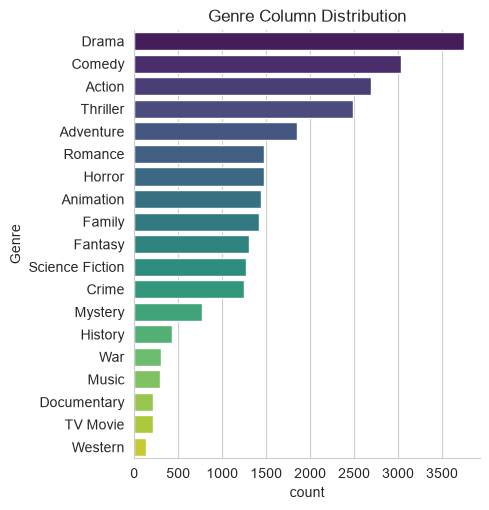

In [26]:

df['Genre'].describe()
sns.catplot(y = 'Genre', data = df , kind = 'count' , 
            order=df['Genre'].value_counts().index, 
            palette='viridis')
plt.title("Genre Column Distribution")
plt.show()

**2. Which has highest votes in vote avg column?**

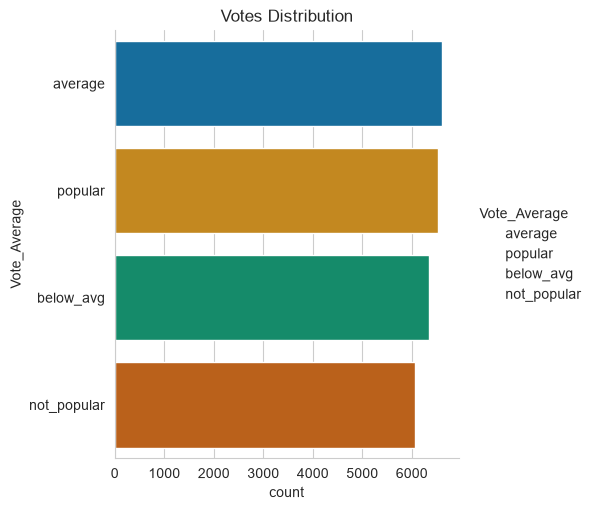

In [30]:
sns.catplot(y = 'Vote_Average' , data = df, kind = 'count',
            order = df['Vote_Average'].value_counts().index,
            palette='colorblind')

plt.title("Votes Distribution")
plt.show()

**3. What movie got the highest popularity? what's its genre?**

In [31]:
df[df['Popularity'] == df['Popularity'].max()]


,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,popular,Science Fiction


**4. What movie got the lowest popularity? what's its genre?**

In [34]:
df[df['Popularity'] == df['Popularity'].min()]


,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
25787,2021,The United States vs. Billie Holiday,13.354,152,average,Music
25788,2021,The United States vs. Billie Holiday,13.354,152,average,Drama
25789,2021,The United States vs. Billie Holiday,13.354,152,average,History
25790,1984,Threads,13.354,186,popular,War
25791,1984,Threads,13.354,186,popular,Drama
25792,1984,Threads,13.354,186,popular,Science Fiction


**5. Which year has the most filmmed movies?**

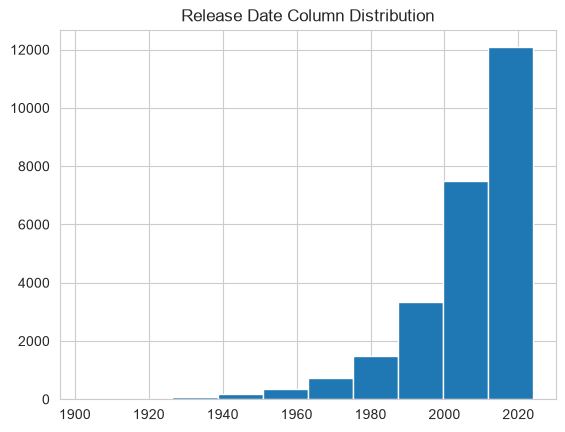

In [35]:
df['Release_Date'].hist()
plt.title('Release Date Column Distribution')
plt.show()

# **Project Completed :)**